# **Support** **Integrity Auditor**
# **(SIA)**

# Stage 1: Pseudo Label Generation

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from google.colab import files

## 2. Load Dataset

In [3]:
uploaded = files.upload()
input_file = next(iter(uploaded))
print("Uploaded file:", input_file)

Saving customer_support_tickets.csv to customer_support_tickets.csv
Uploaded file: customer_support_tickets.csv


## 3. Read and Inspect Dataset

In [4]:
df = pd.read_csv(input_file)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (20000, 12)


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


## 4. Data Cleaning and Preprocessing

In [5]:
required_cols = [
    "Ticket_ID",
    "Customer_Name",
    "Customer_Email",
    "Ticket_Subject",
    "Ticket_Description",
    "Issue_Category",
    "Priority_Level",
    "Ticket_Channel",
    "Submission_Date",
    "Resolution_Time_Hours",
    "Assigned_Agent",
    "Satisfaction_Score"
]

df = df[required_cols].copy()

text_cols = [
    "Customer_Name",
    "Customer_Email",
    "Ticket_Subject",
    "Ticket_Description",
    "Issue_Category",
    "Priority_Level",
    "Ticket_Channel",
    "Submission_Date",
    "Assigned_Agent"
]

for col in text_cols:
    df[col] = df[col].fillna("").astype(str).str.strip()

df["Resolution_Time_Hours"] = pd.to_numeric(df["Resolution_Time_Hours"], errors="coerce")
df["Satisfaction_Score"] = pd.to_numeric(df["Satisfaction_Score"], errors="coerce")

print(df.isna().sum())

Ticket_ID                0
Customer_Name            0
Customer_Email           0
Ticket_Subject           0
Ticket_Description       0
Issue_Category           0
Priority_Level           0
Ticket_Channel           0
Submission_Date          0
Resolution_Time_Hours    0
Assigned_Agent           0
Satisfaction_Score       0
dtype: int64


## 5. Exploratory Data Analysis (EDA)

In [6]:
print("Priority distribution:")
print(df["Priority_Level"].value_counts())

print("\nCategory distribution:")
print(df["Issue_Category"].value_counts())

print("\nResolution time summary:")
print(df["Resolution_Time_Hours"].describe())

print("\nSatisfaction summary:")
print(df["Satisfaction_Score"].describe())

Priority distribution:
Priority_Level
Low         7716
Medium      7570
High        3416
Critical    1298
Name: count, dtype: int64

Category distribution:
Issue_Category
Technical          5918
Billing            5036
Account            4081
General Inquiry    3925
Fraud              1040
Name: count, dtype: int64

Resolution time summary:
count    20000.000000
mean        39.230300
std         35.221884
min          1.000000
25%         11.000000
50%         27.000000
75%         58.000000
max        120.000000
Name: Resolution_Time_Hours, dtype: float64

Satisfaction summary:
count    20000.000000
mean         3.723700
std          1.286989
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Satisfaction_Score, dtype: float64


## 6. Data Visualization

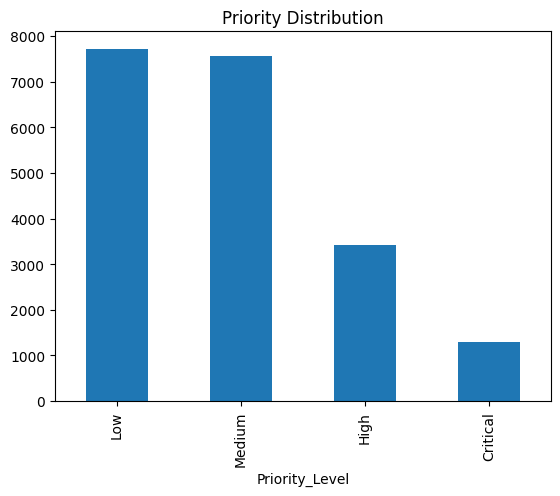

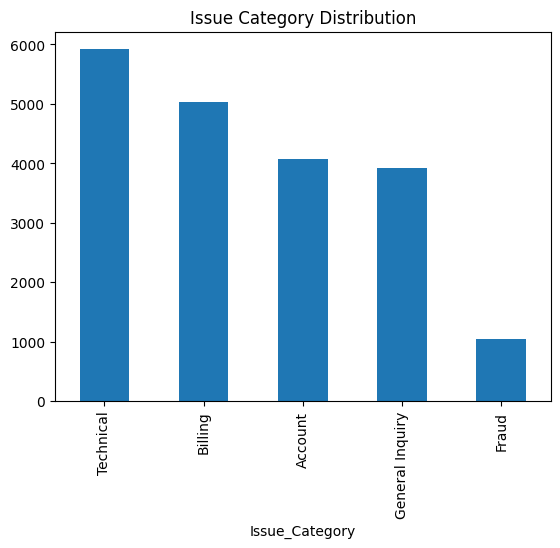

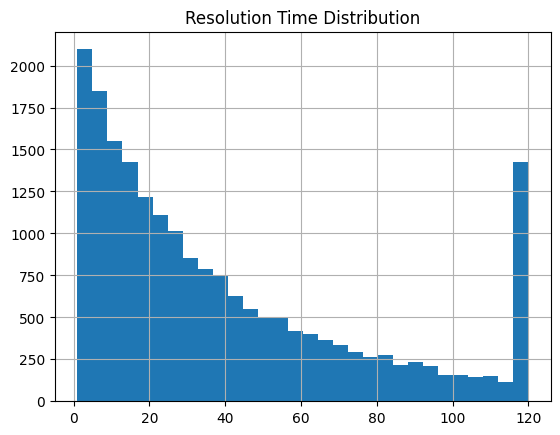

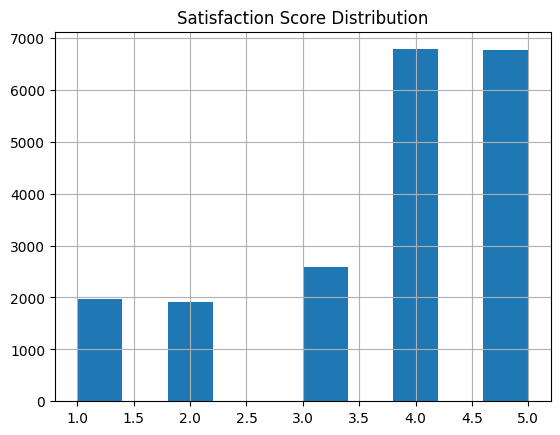

In [7]:
df["Priority_Level"].value_counts().plot(kind="bar", title="Priority Distribution")
plt.show()

df["Issue_Category"].value_counts().plot(kind="bar", title="Issue Category Distribution")
plt.show()

df["Resolution_Time_Hours"].hist(bins=30)
plt.title("Resolution Time Distribution")
plt.show()

df["Satisfaction_Score"].hist(bins=10)
plt.title("Satisfaction Score Distribution")
plt.show()

## 7. Signal Engineering and Score Mapping
#### Convert categorical business signals into numerical scores

In [8]:
priority_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4
}

category_map = {
    "General Inquiry": 1,
    "Account": 2,
    "Billing": 2,
    "Technical": 3,
    "Fraud": 4
}

df = df[df["Priority_Level"].isin(priority_map)].copy()
df = df[df["Issue_Category"].isin(category_map)].copy()

df["assigned_score"] = df["Priority_Level"].map(priority_map).astype(int)
df["category_score"] = df["Issue_Category"].map(category_map).astype(int)

## 8. Severity Knowledge Base Construction
#### Severity phrase dictionary for rule-based signal extraction

In [9]:
SEVERITY_PHRASES = {
    4: [
        "account hacked", "stolen card", "phishing attempt", "suspicious activity",
        "unrecognized login", "unauthorized access", "fraud alert", "identity theft",
        "data breach", "compromised account", "card stolen", "unauthorized transaction"
    ],
    3: [
        "login failed", "api error 500", "screen freezes", "app crashing",
        "data not syncing", "payment failed", "installation issue", "system down",
        "unable to access", "service outage", "transaction declined"
    ],
    2: [
        "refund status", "invoice discrepancy", "update credit card", "charged twice",
        "suspicious charge", "password reset", "2fa issues", "change email",
        "profile update", "delete account", "subscription upgrade", "account recovery"
    ],
    1: [
        "product question", "hours of operation", "demo request", "feature request",
        "office location", "pricing tiers", "general inquiry", "how to use"
    ]
}

## 9. Rule-Based Severity Extraction Functions

In [10]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def keyword_severity(text):
    text = normalize_text(text)
    best = 0
    matched = []
    for sev in sorted(SEVERITY_PHRASES.keys(), reverse=True):
        for phrase in SEVERITY_PHRASES[sev]:
            if phrase in text:
                best = max(best, sev)
                matched.append(phrase)
    return best, matched

## 10. Subject and Description Severity Scoring

In [11]:
subject_res = df["Ticket_Subject"].apply(keyword_severity)
df["subject_score"] = subject_res.apply(lambda x: x[0])
df["subject_hits"] = subject_res.apply(lambda x: "; ".join(x[1]) if x[1] else "")

desc_res = df["Ticket_Description"].apply(keyword_severity)
df["description_score"] = desc_res.apply(lambda x: x[0])
df["description_hits"] = desc_res.apply(lambda x: "; ".join(x[1]) if x[1] else "")

df["text_score"] = df[["subject_score", "description_score"]].max(axis=1)

## 11. Satisfaction Risk Signal Generation

In [12]:
sat = df["Satisfaction_Score"].copy()

# missing values -> median
sat = sat.fillna(sat.median())

sat_min = sat.min()
sat_max = sat.max()

if sat_max == sat_min:
    df["satisfaction_risk"] = 2
else:
    sat_norm = (sat - sat_min) / (sat_max - sat_min)
    # lower satisfaction => higher risk
    df["satisfaction_risk"] = (1 + (1 - sat_norm) * 3).round().astype(int)

df["satisfaction_risk"] = df["satisfaction_risk"].clip(1, 4)

## 12. Final Severity Score Computation

In [13]:
df["final_severity_score"] = (
    0.55 * df["text_score"] +
    0.25 * df["category_score"] +
    0.20 * df["satisfaction_risk"]
).round().clip(1, 4).astype(int)

df["delta"] = df["final_severity_score"] - df["assigned_score"]

## 13. Pseudo Label Generation and Mismatch Detection

In [14]:
def mismatch_label(row):
    diff = int(row["delta"])

    hidden_votes = sum([
        row["subject_score"] > row["assigned_score"],
        row["description_score"] > row["assigned_score"],
        row["category_score"] > row["assigned_score"],
        row["satisfaction_risk"] > row["assigned_score"],
    ])

    false_votes = sum([
        row["subject_score"] < row["assigned_score"],
        row["description_score"] < row["assigned_score"],
        row["category_score"] < row["assigned_score"],
        row["satisfaction_risk"] < row["assigned_score"],
    ])

    if diff >= 2 and hidden_votes >= 1:
        return 1, "Hidden Crisis"
    if diff <= -2 and false_votes >= 1:
        return 1, "False Alarm"

    if diff == 1 and hidden_votes >= 2:
        return 1, "Hidden Crisis"
    if diff == -1 and false_votes >= 2:
        return 1, "False Alarm"

    return 0, "Consistent"

labels = df.apply(mismatch_label, axis=1, result_type="expand")
df["mismatch"] = labels[0].astype(int)
df["mismatch_type"] = labels[1]

## 14. Pseudo Label Validation and Analysis

In [15]:
print("Mismatch distribution:")
print(df["mismatch"].value_counts())

print("\nMismatch type distribution:")
print(df["mismatch_type"].value_counts())

print("\nFirst few rows:")
df[[
    "Ticket_Subject",
    "Issue_Category",
    "Priority_Level",
    "assigned_score",
    "category_score",
    "subject_score",
    "description_score",
    "satisfaction_risk",
    "final_severity_score",
    "delta",
    "mismatch_type"
]].head(10)

Mismatch distribution:
mismatch
1    12160
0     7840
Name: count, dtype: int64

Mismatch type distribution:
mismatch_type
Hidden Crisis    8527
Consistent       7840
False Alarm      3633
Name: count, dtype: int64

First few rows:


,Ticket_Subject,Issue_Category,Priority_Level,assigned_score,category_score,subject_score,description_score,satisfaction_risk,final_severity_score,delta,mismatch_type
0,Hours of operation - Individual,General Inquiry,High,3,1,1,0,1,1,-2,False Alarm
1,Data not syncing - Card,Technical,High,3,3,3,0,1,3,0,Consistent
2,2FA issues - Question,Account,High,3,2,2,0,1,2,-1,False Alarm
3,Login failed - Let,Technical,Low,1,3,3,0,1,3,2,Hidden Crisis
4,Refund status - Attention,Billing,Medium,2,2,2,0,1,2,0,Consistent
5,Office location - National,General Inquiry,Medium,2,1,1,0,2,1,-1,False Alarm
6,Password reset - Body,Account,Medium,2,2,2,0,2,2,0,Consistent
7,Payment failed - Win,Billing,Medium,2,2,3,0,4,3,1,Hidden Crisis
8,Login failed - Son,Technical,High,3,3,3,0,2,3,0,Consistent
9,Product question - Market,General Inquiry,Low,1,1,1,0,2,1,0,Consistent


## 15. Create Final Text Representation for Model Training

In [16]:
df["combined_text"] = (
    "Priority: " + df["Priority_Level"].astype(str) +
    " | Subject: " + df["Ticket_Subject"].astype(str) +
    " | Description: " + df["Ticket_Description"].astype(str) +
    " | Category: " + df["Issue_Category"].astype(str) +
    " | Channel: " + df["Ticket_Channel"].astype(str) +
    " | ResolutionHours: " + df["Resolution_Time_Hours"].astype(str) +
    " | Satisfaction: " + df["Satisfaction_Score"].astype(str)
)

## 16. Export Final Pseudo-Labeled Dataset

In [17]:
output_file = "pseudo_labeled_dataset.csv"
df.to_csv(output_file, index=False)
print("Saved:", output_file)

files.download(output_file)

Saved: pseudo_labeled_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---



---



# Stage 2: Model Training and Evaluation

## 1. GPU Verification

In [18]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## 2. Install Required Dependencies
### Install required libraries for training

In [19]:
!pip install -q transformers==4.52.4 datasets==3.6.0 accelerate sentencepiece evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 122.9 MB/s eta 0:00:00


## 3. Restart Runtime After Dependency Installation

In [ ]:
import os
os.kill(os.getpid(), 9)

## 4. Verify Environment Configuration

In [1]:
import torch
import transformers
import datasets

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
Transformers: 4.52.4
Datasets: 3.6.0
CUDA: True
Tesla T4


In [2]:
import pandas as pd

df = pd.read_csv("pseudo_labeled_dataset.csv")

print(df.shape)
df.head()

(20000, 25)


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,...,subject_hits,description_score,description_hits,text_score,satisfaction_risk,final_severity_score,delta,mismatch,mismatch_type,combined_text
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,...,hours of operation,0,NaN,1,1,1,-2,1,False Alarm,Priority: High | Subject: Hours of operation -...
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,...,data not syncing,0,NaN,3,1,3,0,0,Consistent,Priority: High | Subject: Data not syncing - C...
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,...,2fa issues,0,NaN,2,1,2,-1,1,False Alarm,Priority: High | Subject: 2FA issues - Questio...
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,...,login failed,0,NaN,3,1,3,2,1,Hidden Crisis,Priority: Low | Subject: Login failed - Let | ...
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,...,refund status,0,NaN,2,1,2,0,0,Consistent,Priority: Medium | Subject: Refund status - At...


###Verify Generated Labels
###Check class distribution of generated pseudo labels

In [3]:
print(df["mismatch"].value_counts())
print(df["mismatch"].unique())

mismatch
1    12160
0     7840
Name: count, dtype: int64
[1 0]


## 5. Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["mismatch"]
)

print(train_df.shape)
print(test_df.shape)

(16000, 25)
(4000, 25)


###Prepare Text Data for Training

In [5]:
train_df = train_df.copy()
test_df = test_df.copy()

train_df["text"] = train_df["combined_text"]
test_df["text"] = test_df["combined_text"]

### Convert pandas DataFrames to Hugging Face Dataset format

In [6]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "mismatch"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "mismatch"]]
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'mismatch', '__index_level_0__'],
    num_rows: 16000
})
Dataset({
    features: ['text', 'mismatch', '__index_level_0__'],
    num_rows: 4000
})


##6. Load DistilBERT Tokenizer

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

###Convert text into token IDs and attention masks

In [8]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

###Apply tokenizer to train and test datasets

In [9]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

###Rename Target Column for Hugging Face Trainer

In [10]:
train_dataset = train_dataset.rename_column(
    "mismatch",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "mismatch",
    "labels"
)

###Remove Unused Columns

In [11]:
train_dataset = train_dataset.remove_columns(
    ["text", "__index_level_0__"]
)

test_dataset = test_dataset.remove_columns(
    ["text", "__index_level_0__"]
)

###Verify final dataset format before training

In [12]:
print(train_dataset.features)
print(train_dataset[0])

{'labels': Value(dtype='int64', id=None), 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}
{'labels': 0, 'input_ids': [101, 9470, 1024, 2659, 1064, 3395, 1024, 2847, 1997, 3169, 1011, 4111, 1064, 6412, 1024, 7632, 2490, 1010, 2079, 2017, 3749, 1037, 19575, 2005, 2512, 1011, 11372, 1029, 3460, 4521, 3105, 8339, 2569, 7155, 3921, 5454, 1012, 1064, 4696, 1024, 2236, 9934, 1064, 3149, 1024, 11834, 1064, 5813, 6806, 9236, 1024, 4029, 1064, 9967, 1024, 1016, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 

## 7. Load DistilBERT Classification Model

In [13]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print(model.config.num_labels)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


2


###Define Evaluation Metrics
###Evaluation metrics used for model assessment

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "recall": recall_score(labels, preds, average="macro")
    }

###Define training configuration and hyperparameters

In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    fp16=True,

    report_to="none"
)

##8. Initialize Trainer

In [16]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

##Train DistilBERT Model

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Recall
1,0.050100,0.046925,0.977500,0.976283,0.974020
2,0.031500,0.011117,0.994500,0.994227,0.993891
3,0.005000,0.000480,1.000000,1.000000,1.000000


TrainOutput(global_step=6000, training_loss=0.05824513079722722, metrics={'train_runtime': 379.5757, 'train_samples_per_second': 126.457, 'train_steps_per_second': 15.807, 'total_flos': 1589608783872000.0, 'train_loss': 0.05824513079722722, 'epoch': 3.0})

###Evaluate Model Performance

In [18]:
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.00048014381900429726, 'eval_accuracy': 1.0, 'eval_macro_f1': 1.0, 'eval_recall': 1.0, 'eval_runtime': 5.257, 'eval_samples_per_second': 760.887, 'eval_steps_per_second': 95.111, 'epoch': 3.0}


###Save Trained Model

In [19]:
trainer.save_model("sia_model")
tokenizer.save_pretrained("sia_model")

('sia_model/tokenizer_config.json',
 'sia_model/special_tokens_map.json',
 'sia_model/vocab.txt',
 'sia_model/added_tokens.json',
 'sia_model/tokenizer.json')

Generate Classification Report

In [20]:
preds = trainer.predict(test_dataset)

import numpy as np
from sklearn.metrics import classification_report

y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1568
           1       1.00      1.00      1.00      2432

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

